# Motivación:

Las pruebas de bondad de ajuste son de gran utilidad cuando se busca **ajustar** una distribución, así como si solo es de interés **verificar** si una variable/muestra proviene de cierta distribución.

En particular, dentro de la estadística, a menudo resulta de interés que una variable provenga de una distribución Normal, pues esto permite realizar pruebas de hipótesis, intervalos de confianza, y el uso de resultados de convergencia asintótica. En inferencia estadística teníamos _pruebas t_, que sirven para realizar pruebas de medias, para una o dos poblaciones. En Análisis multivariado existe una idea análoga, bajo Normalidad Multivariada las _pruebas $T^2$ de Hotelling_.

Modelos de Regresión no es la excepción, pues un supuesto fundamental de la regresión lineal es que los errores provengan de una distribución Normal.


In [1]:
# Fijar una semilla
set.seed(123)

# **Pruebas de Normalidad**

Antes de pasar a las pruebas de bondad de ajuste, que son una herramienta analítica para verificar el ajuste de nuestros datos con respecto a una distribución Normal, existe una herramienta visual.


## **Q-Q Plot** (Quantile-Quantile Plot)

Es una herramienta gráfica que ayuda a comparar los cuantiles de una distribución teórica contra los cuantiles de una muestra de datos. En particular nos interesa **Normal Q-Q Plot** el cual visualiza los cuantiles teóricos de una normal contra los cuantiles de nuestros datos (suele compararse con una Normal estándar o una Normal con la media y varianza muestral).

La idea de este gráfico es que si los datos siguen una distribución Normal, los cuantiles teóricos deberían ser similares a los cuantiles observados. Si graficamos la recta Identidad, los puntos deberían estar cercanos a esta recta, indicando que los cuantiles son similares.

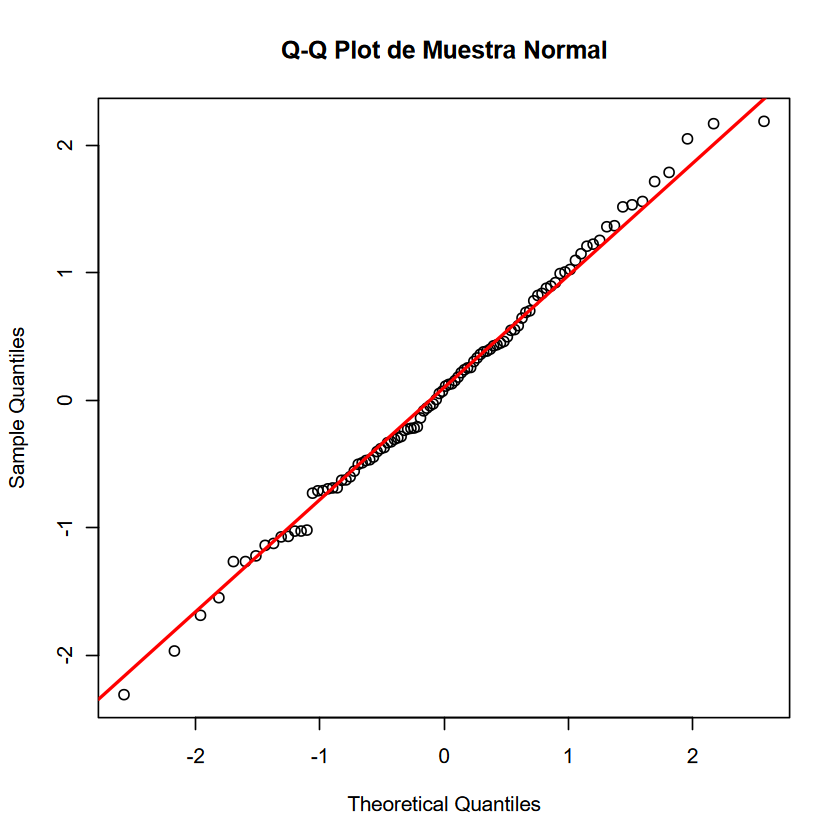

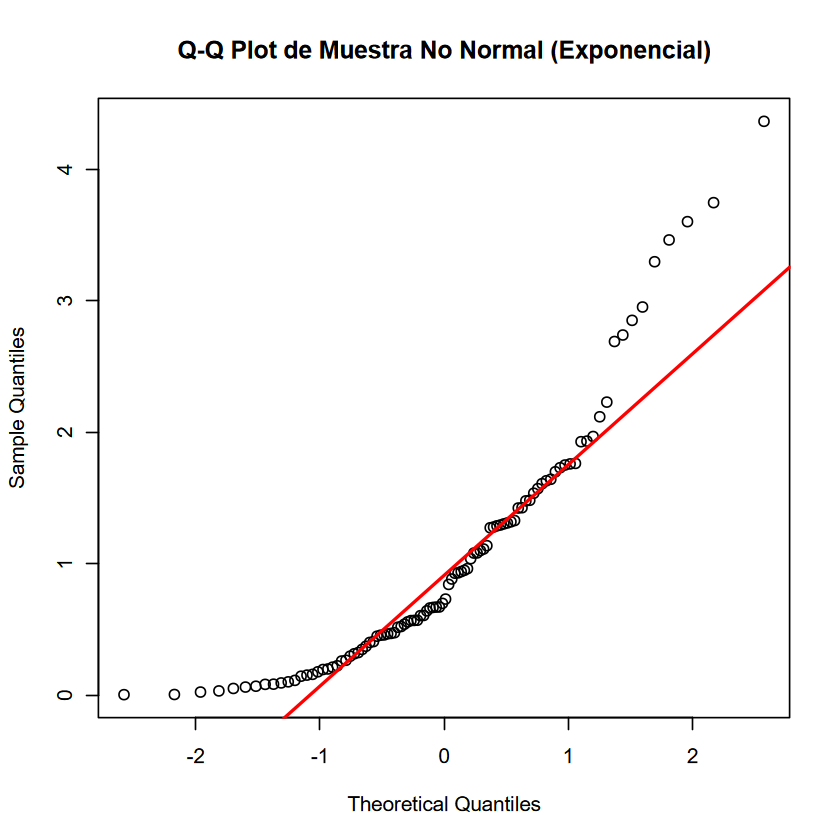

In [2]:
# Generar muestras
muestra_normal <- rnorm(100, mean = 0, sd = 1)
muestra_no_normal <- rexp(100, rate = 1)

# Configurar la ventana gráfica
par(mfrow = c(1, 1))  # dos gráficos en una fila

# Q-Q plot para muestra normal
qqnorm(muestra_normal, main = "Q-Q Plot de Muestra Normal")
qqline(muestra_normal, col = "red", lwd = 2)

# Q-Q plot para muestra no normal
qqnorm(muestra_no_normal, main = "Q-Q Plot de Muestra No Normal (Exponencial)")
qqline(muestra_no_normal, col = "red", lwd = 2)


Se puede observar algunos detalles del QQ-Plot de la muestra exponencial, por ejemplo...

A continuacion, presentaremos algunas de las pruebas de Bondad de Ajuste mas populares, que comunmente se utilizan para verificar que los datos provengan de una distribucion Normal.

## **Kolmogorov-Smirnov**


No es exclusiva para Normalidad, sino que puede emplearse para contrastar una muestra con cualquier distribución teórica especificada. Evalúa la máxima diferencia entre la función de distribución empírica $F_{n}(x)$ y la función de distribución teórica $F(x)$, considerando todo el rango de la variable. Es más sensible a discrepancias en la parte central de la distribución que en las colas.

$H_{0}: X \sim D(\theta) \quad \text{vs} \quad H_{1}: X \nsim D(\theta)$

El estadístico de prueba se define como:

$D = \sup_{x} |F_{n}(x) - F(x)|$

La regla de decisión consiste en rechazar $H_{0}$ si $D > D^{1-\alpha}$, donde $D^{1-\alpha}$ representa el valor crítico de la distribución del estadístico de Kolmogorov-Smirnov, el cual depende del tamaño de la muestra, del nivel de significancia.

**Teorema Glivenko-Cantelli**

  
  La prueba se basa en la convergencia de la distribución empírica a la distribución real de los datos. Visualmente se puede apreciar, simulando 6 veces una muestra normal estándar de distinto tamaño de muestra, pese a que cada iteración la muestra vuelve a ser simulada, se puede observar como a medida que el tamaño de muestra es mayor, la similitud con la distribución real (una Normal estándar) es cada vez mayor.




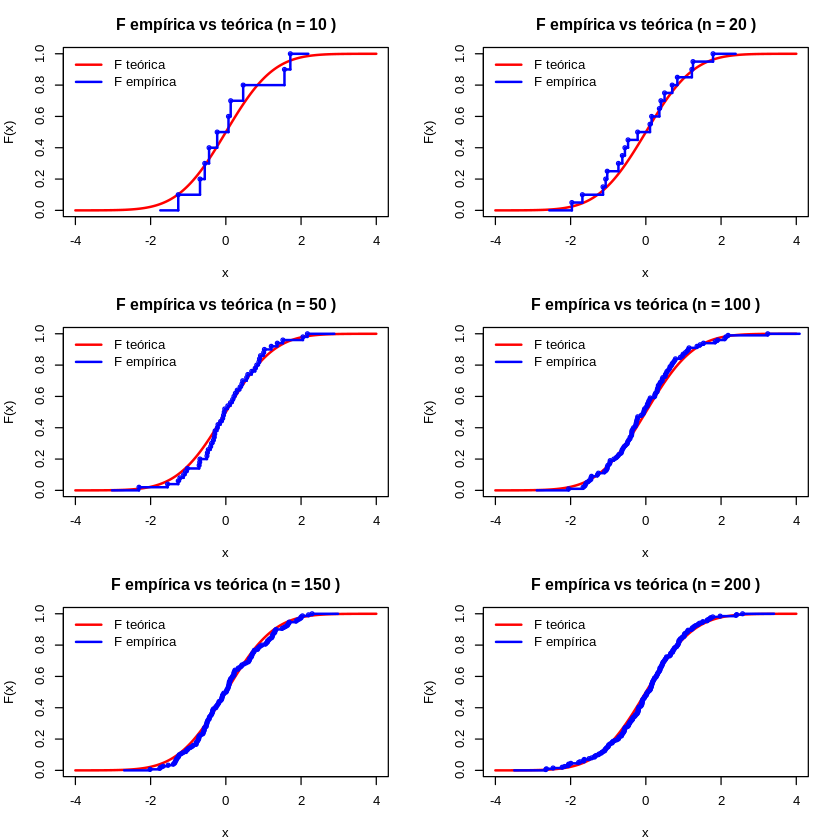

In [ ]:


x_grid <- seq(-4, 4, length.out = 2000)
F_teorica <- pnorm(x_grid)
n_valores <- c(10,20, 50, 100, 150,200)

par(mfrow = c(3, 2), mar = c(4, 4, 3, 2))

for (n in n_valores) {
  muestra <- rnorm(n)
  F_empirica <- ecdf(muestra)

  plot(x_grid, F_teorica, type = "l", lwd = 2, col = "red",
       ylim = c(0, 1), xlab = "x", ylab = "F(x)",
       main = paste("F empírica vs teórica (n =", n, ")"))
  lines(stepfun(sort(muestra), c(0, (1:n)/n)), col = "blue", lwd = 2)
  legend("topleft",
         legend = c("F teórica", "F empírica"),
         col = c("red", "blue"), lwd = 2, bty = "n")
}


Ilustrando la idea del estadistico de prueba $D = \sup_{x} |F_{n}(x) - F(x)|$


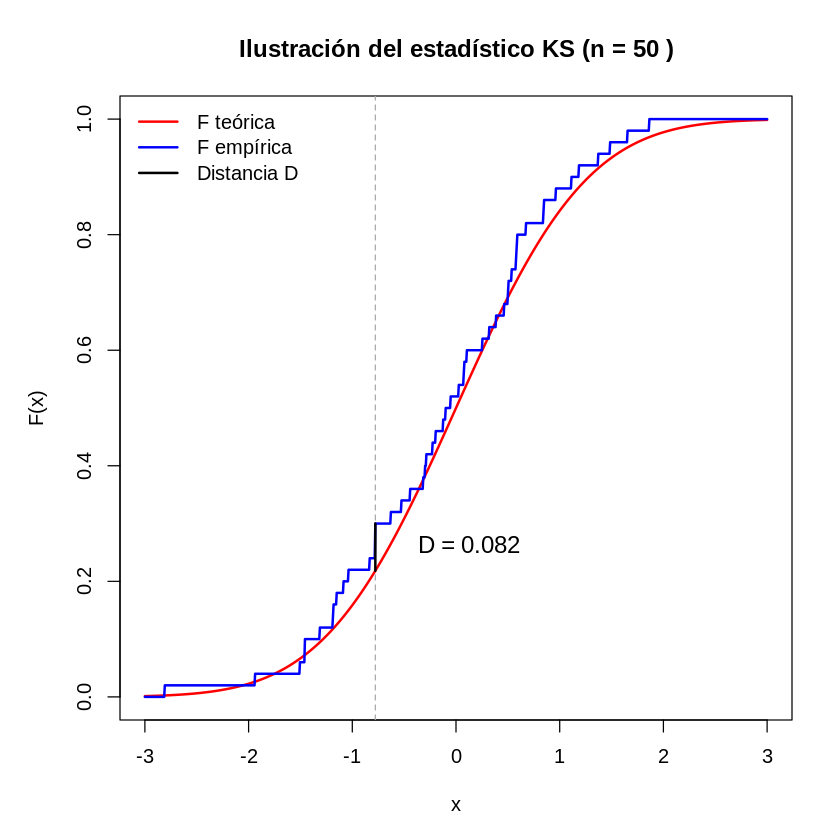

In [ ]:

n <- 50
muestra <- rnorm(n)
x_grid <- seq(-3, 3, length.out = 1000)

F_teorica <- pnorm(x_grid)
F_empirica <- ecdf(muestra)(x_grid)

diferencias <- abs(F_empirica - F_teorica)
D <- max(diferencias)
x_D <- x_grid[which.max(diferencias)]

par(mfrow = c(1,1), mar = c(5,5,4,2))
plot(x_grid, F_teorica, type = "l", lwd = 2, col = "red",
     ylim = c(0,1), xlab = "x", ylab = "F(x)",
     main = paste("Ilustración del estadístico KS (n =", n, ")"))
lines(x_grid, F_empirica, col = "blue", lwd = 2)
abline(v = x_D, lty = 2, col = "darkgray")
segments(x_D, F_teorica[which.max(diferencias)],
         x_D, F_empirica[which.max(diferencias)],
         col = "black", lwd = 2)
legend("topleft",
       legend = c("F teórica", "F empírica", "Distancia D"),
       col = c("red", "blue", "black"),
       lwd = c(2,2,2),
       lty = c(1,1,1),
       bty = "n")

text(x_D + 0.3, mean(c(F_teorica[which.max(diferencias)],
                       F_empirica[which.max(diferencias)])),
     labels = bquote(D == .(round(D, 3))),
     cex = 1.2, pos = 4)


In [ ]:
ks.test(muestra_normal, "pnorm", mean = 0, sd = 1)




	Asymptotic one-sample Kolmogorov-Smirnov test

data:  muestra_normal
D = 0.05937, p-value = 0.8725
alternative hypothesis: two-sided


## **Anderson-Darling**

No es exclusiva para Normalidad, se basa en hacer enfasis en el ajuste de las colas de la distribucion, útil para muestras "medianas"
($50\leq n \leq 500$)

$H_{0}: X \sim D(\theta) \text{     vs    } H_{1}: X \nsim D(\theta)$


La prueba AD define al estadístico de prueba: $ A^{2}=n \int_{-\infty}^{\infty}(F_{n}(x_{i}) - F(x_{i}))^{2} \frac{1}{F(x_{i})(1-F(x_{i})))} dX $

La regla de decisión: Rechazar $H_{0}$ si $A^{2}>W^{1-\alpha}$

Donde $W^{1-\alpha}$ es el cuantil/valor crítico de la distribución de $A^{2}$, el cual depende de la cantidad de muestra y del nivel de significancia, asi como de la distribución que se desea probar.



Se dice que la prueba realiza un énfasis en el ajuste de las colas de la distribución debido a que $f(x)=\frac{1}{x(1-x)}$ para $x \in (0,1)$ tiene la siguiente forma:

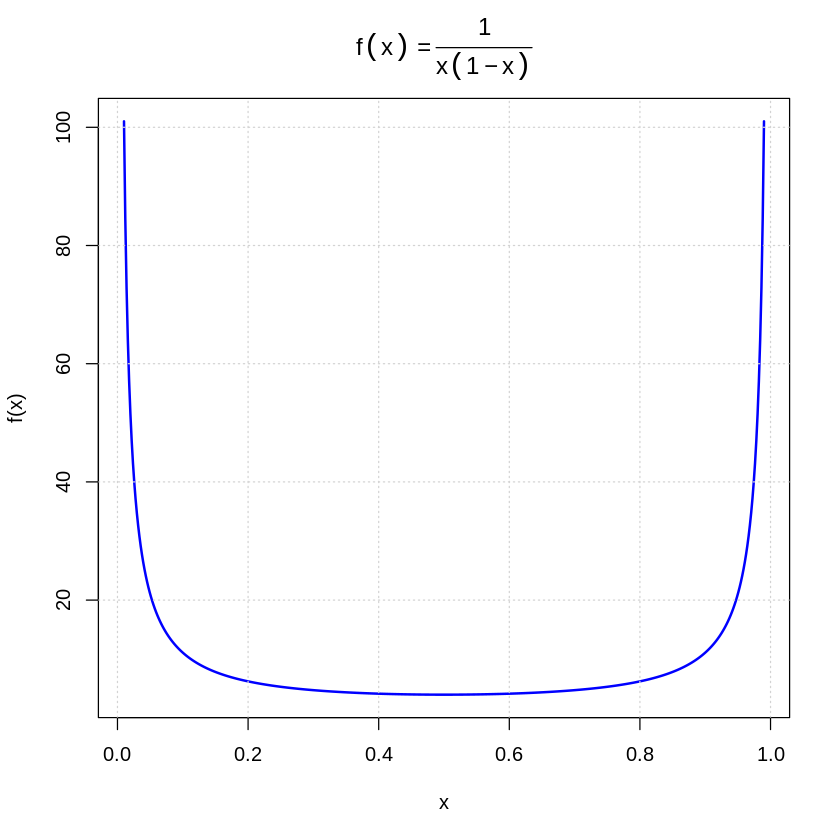

In [ ]:
f <- function(x) {
  1 / (x * (1 - x))
}

x <- seq(0.01, 0.99, length.out = 500)
y <- f(x)

plot(x, y, type = "l", lwd = 2,
     xlab = "x", ylab = "f(x)",
     main = expression(f(x) == frac(1, x * (1 - x))),
     col = "blue")
grid()


Por lo que en las colas de la distribución, es decir, cuando $F(x) ≈ 0$ o $F(x) ≈ 1$, la función $f(x)=\frac{1}{x(1-x)}$ penaliza "más" las diferencias $(F_{n}(x_{i}) - F(x_{i}))^{2}$

In [ ]:

library(nortest)

#por la libreria se especifica que es para probar normalidad
#estima los parametros
ad.test(muestra_normal)



	Anderson-Darling normality test

data:  muestra_normal
A = 0.509, p-value = 0.1939


## **Shapiro-Wilks**



Exclusiva para Normalidad, basada en la correlación entre los datos ordenados y los cuantiles de una Normal. Util con muestras pequeñas ($n\leq50$)

$H_{0}: X \sim N(\mu, \sigma^{2}) \text{     vs    } H_{1}: X \nsim N(\mu, \sigma^{2})$

La prueba de Shapiro-Wilk define el estadístico de prueba:

$W = \frac{\left(\sum_{i=1}^{n} a_i x_{(i)}\right)^2}
{\sum_{i=1}^{n}
(x_i - \bar{x})^{2}}$

donde:

- $ x_{(i)} $ son los valores ordenados de la muestra (orden estadístico).
- $ \bar{x} $ es la media muestral.
- $ a_i $ son coeficientes predefinidos que dependen del tamaño de la muestra $n$.

La regla de decisión: Rechazar $ H_0$ si $ p-value \leq \alpha $.


In [ ]:

shapiro.test(muestra_normal)



	Shapiro-Wilk normality test

data:  muestra_normal
W = 0.98476, p-value = 0.3052


## **Jarque-Bera**

Exclusiva para Normalidad, basada en la asimetría y curtosis de los datos, util para muestras grandes ($n\geq 500$)


$H_{0}: X \sim N(\mu, \sigma^{2}) \text{     vs    } H_{1}: X \nsim N(\mu, \sigma^{2})$

La prueba de Jarque-Bera define el estadístico de prueba:

$ JB = \frac{n}{6} \left( S^2 + \frac{(K - 3)^2}{4} \right) $

donde:

- $ n $ es el tamaño de la muestra.
- $ S $ es el coeficiente de **asimetría (skewness)**.
- $ K $ es el coeficiente de **curtosis (kurtosis)**.

Bajo $ H_0 $, el estadístico $JB \sim \chi^{2}_{2}$

La regla de decisión: Rechazar $ H_0 $ si $ JB > \chi^{2(1-\alpha)}_{2} $

Donde $ \chi^{2(1-\alpha)}_{2}$ es el cuantil de orden $1-\alpha$ de  $\chi^{2}_{2}$


In [ ]:

library(tseries)



jarque.bera.test(muestra_normal)



Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘xts’, ‘TTR’, ‘quadprog’, ‘zoo’, ‘quantmod’


Registered S3 method overwritten by 'quantmod':
  method            from
  as.zoo.data.frame zoo 




	Jarque Bera Test

data:  muestra_normal
X-squared = 1.5989, df = 2, p-value = 0.4496


## "Automatizando" en pañales

Nos gustaria usar todas ...

**Primera propuesta...**

----- Resumen -----
Número de observaciones: 100 
Media: 0.0938 
Desviación estándar: 0.9136 
Mediana: 0.0906 
Mínimo: -2.3092 
Máximo: 2.1873 

Estimación de parámetros MLE:
Media (mu_hat): 0.0938 
Desviación estándar (sigma_hat): 0.9136 


-----  Shapiro-Wilk  -----
Estadístico = 0.9945 , p-value = 0.9599 

-----  Anderson-Darling  -----
Estadístico = 0.1475 , p-value = 0.9647 

-----  Jarque-Bera  -----
Estadístico = 0.1541 , p-value = 0.9258 

-----  Kolmogorov-Smirnov  -----
Estadístico = 0.0494 , p-value = 0.9677 


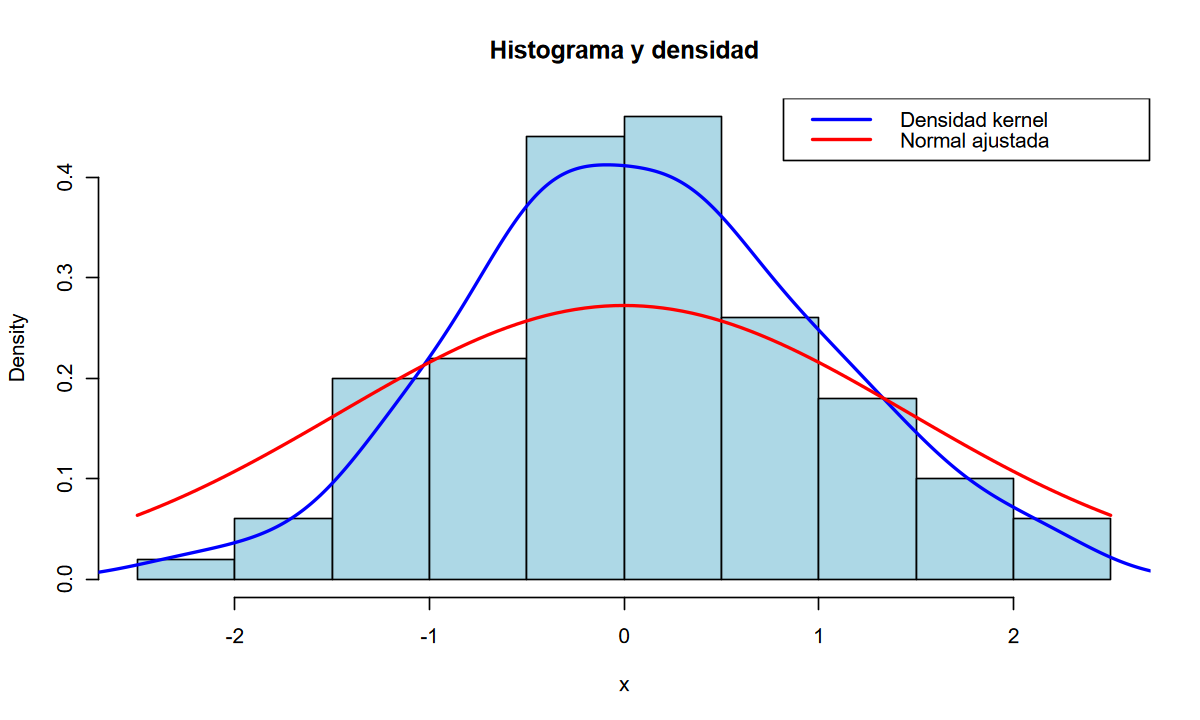

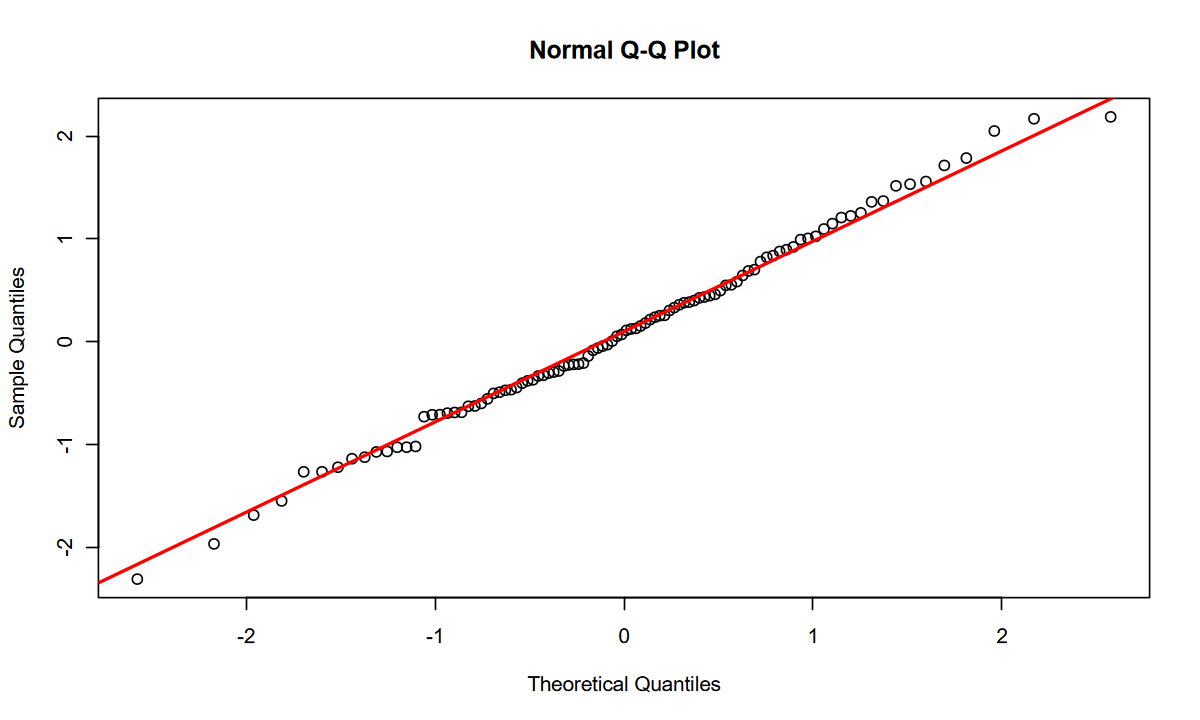

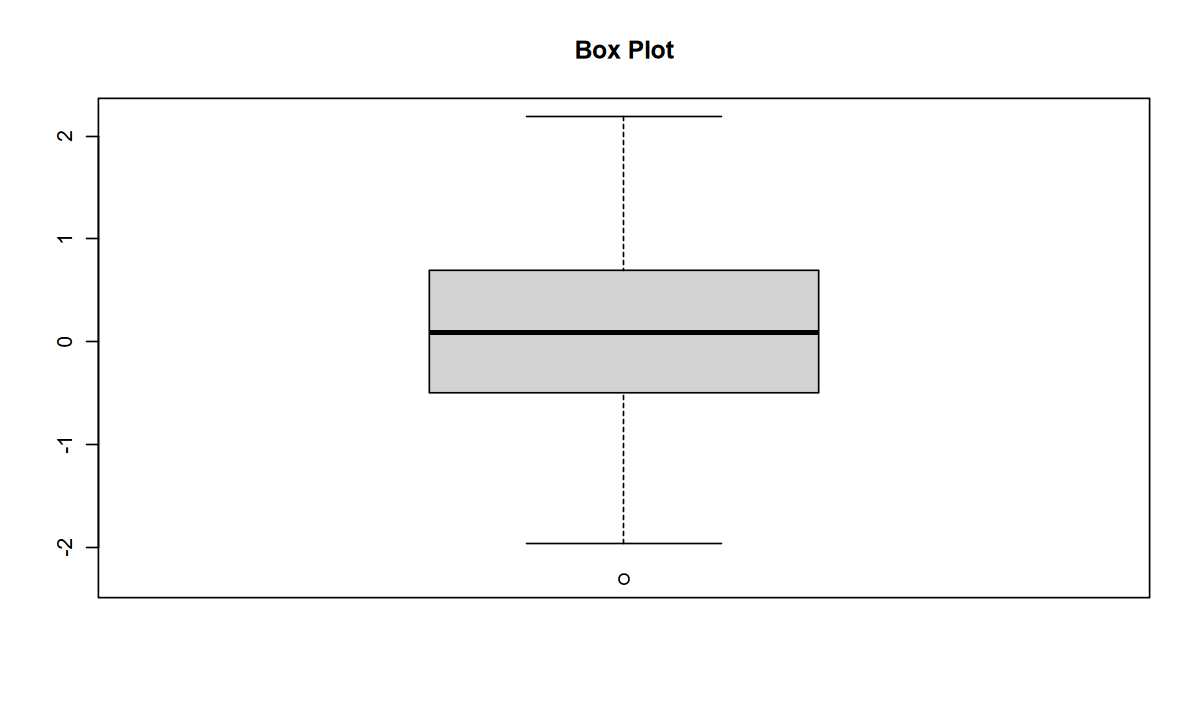

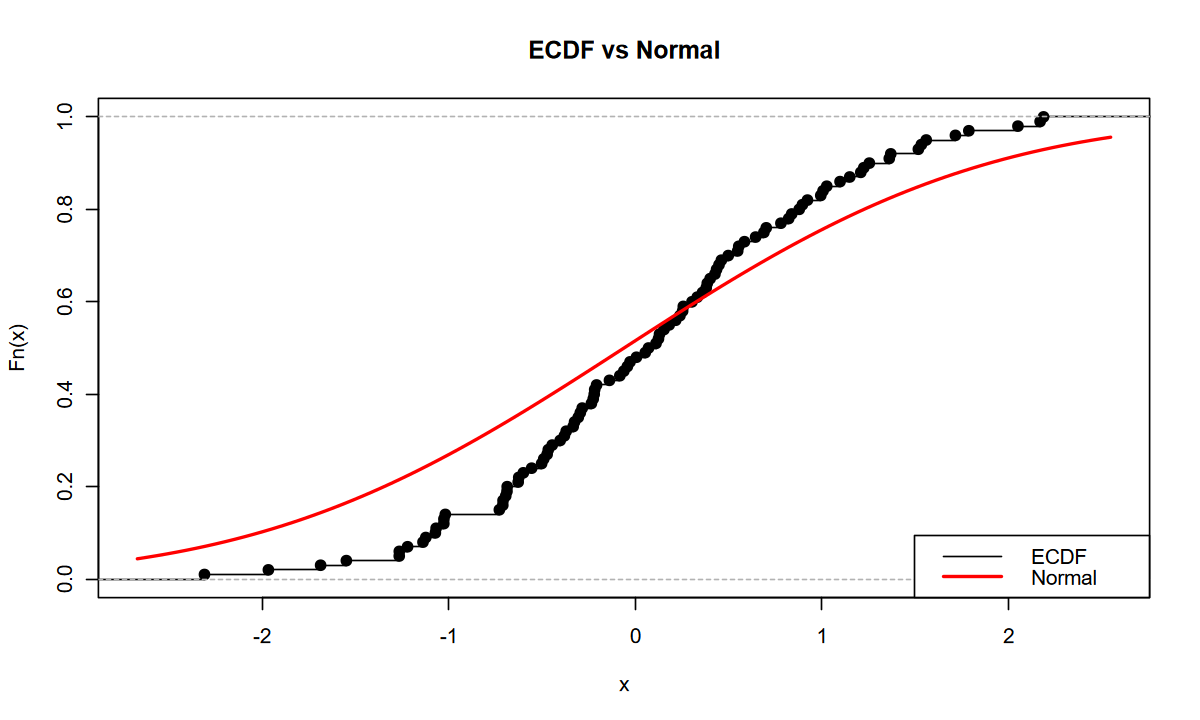

In [4]:
library(nortest)
library(tseries)


normality_summary_plot <- function(x) {
 
  # summary
  n <- length(x)
  mean_x <- mean(x)
  sd_x <- sd(x)
  min_x <- min(x)
  max_x <- max(x)
  median_x <- median(x)
  summary_stats <- summary(x)

  cat("----- Resumen -----\n")
  cat("Número de observaciones:", n, "\n")
  cat("Media:", round(mean_x, 4), "\n")
  cat("Desviación estándar:", round(sd_x, 4), "\n")
  cat("Mediana:", round(median_x, 4), "\n")
  cat("Mínimo:", round(min_x, 4), "\n")
  cat("Máximo:", round(max_x, 4), "\n\n")

  cat("Estimación de parámetros MLE:\n")
  cat("Media (mu_hat):", round(mean_x, 4), "\n")
  cat("Desviación estándar (sigma_hat):", round(sd_x, 4), "\n\n")
  
  # Pruebas de normalidad
  tests <- list(
    "Shapiro-Wilk" = shapiro.test(x),
    "Anderson-Darling" = nortest::ad.test(x),
    "Jarque-Bera" = tseries::jarque.bera.test(x),
    "Kolmogorov-Smirnov" = ks.test(x, "pnorm", mean=mean(x), sd=sd(x))
  )
  
  for (test_name in names(tests)) {
    cat("\n----- ", test_name, " -----\n")
    cat("Estadístico =", round(tests[[test_name]]$statistic, 4),
        ", p-value =", round(tests[[test_name]]$p.value, 4), "\n")
  }
  # configuracion para notebook
  options(repr.plot.width=10, repr.plot.height=6)
  
  par(mfrow=c(1,1))

  # histograma con densidad
  hist(x, prob=TRUE, main="Histograma y densidad", col="lightblue")
  lines(density(x), col="blue", lwd=2)
  curve(dnorm(x, mean=mean(x), sd=sd(x)), add=TRUE, col="red", lwd=2)
  legend("topright", legend=c("Densidad kernel", "Normal ajustada"),
         col=c("blue", "red"), lwd=2)
  
  # Q-Q plot
  qqnorm(x)
  qqline(x, col="red", lwd=2)
  
  # 3. boxplot
  boxplot(x, main="Box Plot")
  
  # ECDF vs Normal
  plot(ecdf(x), main="ECDF vs Normal")
  curve(pnorm(x, mean=mean(x), sd=sd(x)), add=TRUE, col="red", lwd=2)
  legend("bottomright", legend=c("ECDF", "Normal"), 
         col=c("black", "red"), lwd=c(1,2))
  
  par(mfrow=c(1,1))
}

  

normality_summary_plot(muestra_normal)
